In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [1]:


from Nozzle_2D_checkpoint4_1 import Nozzle
import matplotlib.pyplot as plt
import numpy as np
import pickle



In [2]:
SUPERCOARSE = Nozzle("inputs/Medium_inputs.nml")
SUPERCOARSE.CFL = .1


self = SUPERCOARSE 
self.CFL = .0000001
self.iter_max = 78000

# RUN MEDIUM SIMULATION
self.set_arrays()
#self.set_curved_geometry()
self.load_grid("Meshes/NACA64A006.coarse.53x27.grd")
self.set_normals()
self.compute_all_areas()
self.is_foil = True


In [6]:
(self.y).tofile("Airfoil_Coarse_yy.bin")

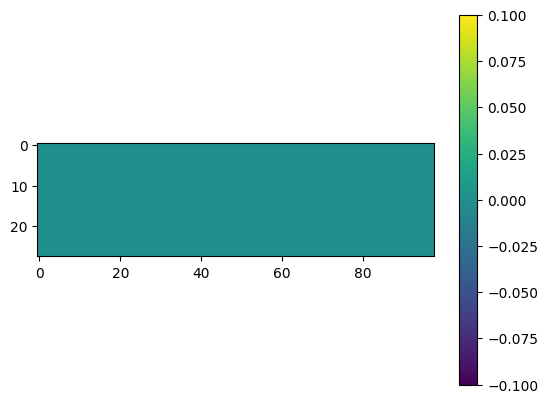

In [4]:
#self.set_initial_conditions2(direction="down")
self.set_initial_foil_conditions(boundary_mach=.15)
self.set_foil_inflow(boundary_mach=.15)
#self.set_inflow_conditions(direction="down",boundary_mach=.075)
R0 = np.linalg.norm(self.iteration_step()[0])
plt.imshow(self.V[2,::-1])
plt.colorbar()

In [5]:
#self.V = np.load("checkpoint_V001.npy")
#self.U = np.load("checkpoint_U001.npy")

In [6]:
self.CFL = .001
for i in range(400000):

    #self.set_inflow_conditions(direction="down")
    self.set_foil_inflow(boundary_mach=.15)
    R1 = self.iteration_step()
    self.V[:,:,0] = self.V[:,:,1]
    self.V[:,:,-1] = self.V[:,:,-2]
    self.set_normal_bcs_FOIL()
    #self.set_normal_bcs()
    print(f"Iteration{i}  ",np.linalg.norm(R1[0])/(R0))
plt.imshow(self.V[1,::-1])
plt.colorbar()


Iteration0   0.999999994262287
Iteration1   0.9999462546312196
Iteration2   0.9998889513638121
Iteration3   0.9998317063342089
Iteration4   0.9997745194893675
Iteration5   0.9997173907762986
Iteration6   0.9996603201420676
Iteration7   0.9996033075337937
Iteration8   0.9995463528986498
Iteration9   0.9994894561838624
Iteration10   0.9994326173367128
Iteration11   0.9993758363045351
Iteration12   0.9993191130347172
Iteration13   0.9992624474747009
Iteration14   0.9992058395719818
Iteration15   0.9991492892741084
Iteration16   0.999092796528683
Iteration17   0.9990363612833616
Iteration18   0.998979983485853
Iteration19   0.9989236630839198
Iteration20   0.9988674000253774
Iteration21   0.998811194258095
Iteration22   0.9987550457299942
Iteration23   0.9986989543890508
Iteration24   0.9986429201832923
Iteration25   0.9985869430608002
Iteration26   0.9985310229697083
Iteration27   0.998475159858204
Iteration28   0.998419353674527
Iteration29   0.99836360436697
Iteration30   0.998307911883

KeyboardInterrupt: 

In [7]:
#np.save("checkpoint_V001",self.V)
#np.save("checkpoint_U001",self.U)

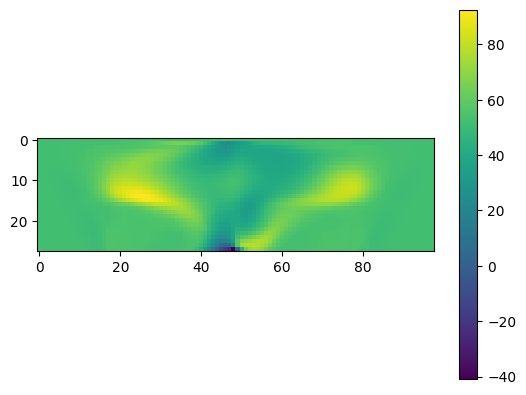

In [8]:

plt.imshow(self.V[1,::-1])
plt.colorbar()

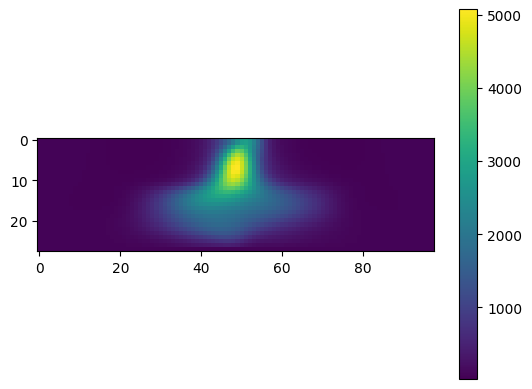

In [9]:
plt.imshow(self.V[3])
plt.colorbar()

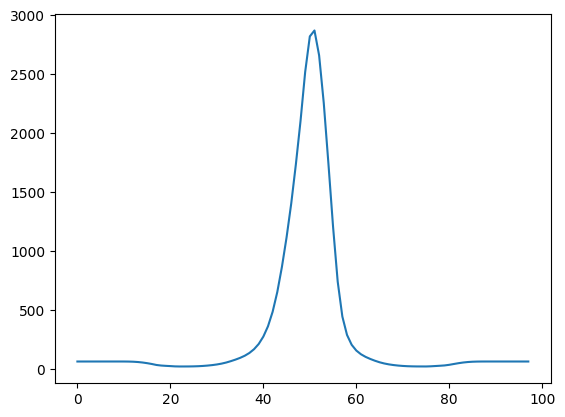

In [10]:
plt.plot(self.V[3,0,:])

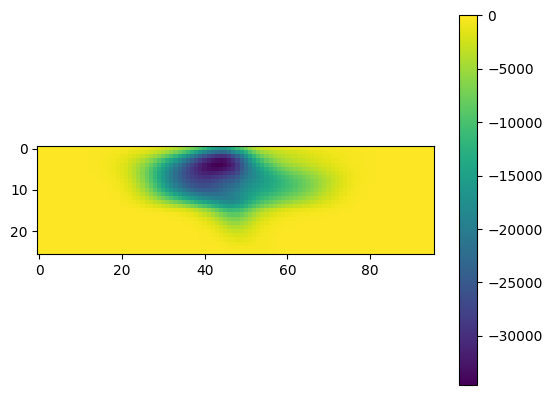

In [11]:
plt.imshow(R1[3,::-1])
plt.colorbar()

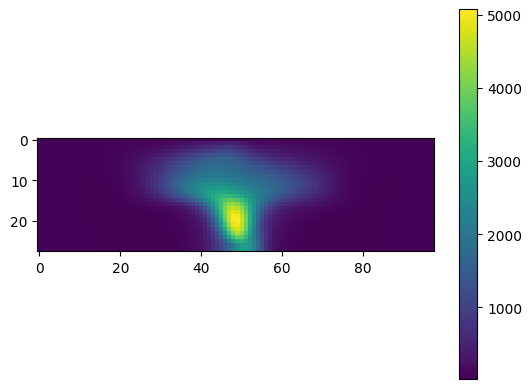

In [12]:

plt.imshow(self.V[3,::-1])
plt.colorbar()

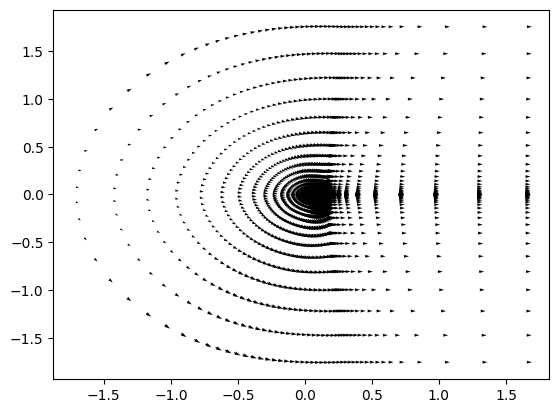

In [13]:
self.plot_primitive("velocity")



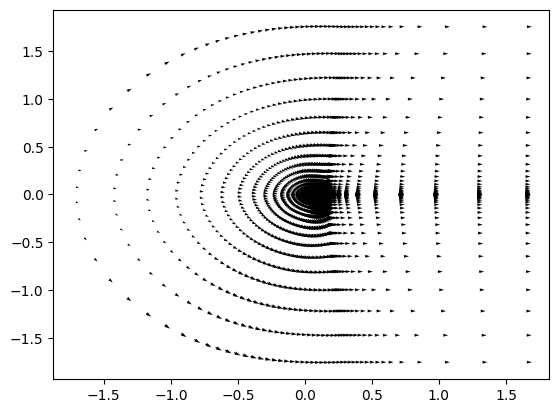

In [14]:
midpoint_tempx = (self.x[1:,:]+self.x[0:-1,:])/2
midpointxx = (midpoint_tempx[:,1:]+midpoint_tempx[:,0:-1])/2
midpoint_tempy = (self.y[1:,:]+self.y[0:-1,:])/2
midpointyy = (midpoint_tempy[:,1:]+midpoint_tempy[:,0:-1])/2


plt.quiver(midpointxx,midpointyy,self.V[self.u_idx,1:-1,1:-1],self.V[self.v_idx,1:-1,1:-1])

In [17]:
import pyvista as pv

midpoint_tempx = (self.x[1:,:]+self.x[0:-1,:])/2
midpointxx = (midpoint_tempx[:,1:]+midpoint_tempx[:,0:-1])/2
midpoint_tempy = (self.y[1:,:]+self.y[0:-1,:])/2
midpointyy = (midpoint_tempy[:,1:]+midpoint_tempy[:,0:-1])/2



xx = midpointxx
grid = pv.StructuredGrid(midpointxx,midpointyy, np.zeros_like(self.V[self.p_idx,1:-1,1:-1]))

grid["pressure"] = self.V[self.p_idx,1:-1,1:-1].T.flatten()
Ux = self.V[self.u_idx,1:-1,1:-1].T
Uy = self.V[self.v_idx,1:-1,1:-1].T
vel = np.stack([Ux, Uy, np.zeros_like(Ux)], axis=-1).reshape(-1, 3)
grid["velocity"] = vel
grid.save("output.vtk")  # or .vtu

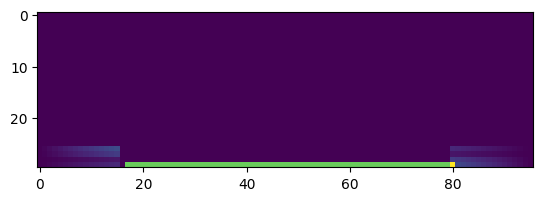

In [18]:
F_temp = np.sin(2+np.zeros((self.V.shape[1]+2, self.V.shape[2]-2)))
num_vals = 16

(F_temp[2,self.NJ-num_vals-1:])[::-1] = np.array([i for i in range(16)])
(F_temp[3,self.NJ-num_vals-1:])[::-1] = np.array([2*i for i in range(16)])
F_temp[2,0:num_vals] = np.array([3*i for i in range(16)])
F_temp[3,0:num_vals] = np.array([4*i for i in range(16)])


F_temp[0,0:num_vals] = (F_temp[3,self.NJ-num_vals-1:])[::-1]
F_temp[1,0:num_vals] = (F_temp[2,self.NJ-num_vals-1:])[::-1]

(F_temp[0,self.NJ-num_vals-1:]) = F_temp[3,0:num_vals][::-1]
(F_temp[1,self.NJ-num_vals-1:]) = F_temp[2,0:num_vals][::-1]

top,bottom = self.get_boundary_conditions_NORMALS()
F_temp[0,num_vals+1:self.NJ-num_vals] = 200+(F_temp[0,num_vals+1:self.NJ-num_vals])


plt.imshow(F_temp[::-1])